# MNIST: Principal Component Analysis for Dimensionality Reduction and Classification

## Project Overview

This notebook examines Principal Component Analysis (PCA) on MNIST from both a mathematical and applied machine-learning perspective.

The workflow verifies PCA component properties, reconstructs the transformation manually, studies explained variance and image reconstruction, and measures how the number of retained principal components affects several classifiers.

### Technical Coverage

- MNIST preprocessing and one-hot encoding
- 30-component PCA property checks
- 392-component dimensionality reduction
- component norms and orthogonality
- visualization of principal-component images
- manual PCA transformation
- transformation-equivalence verification
- explained-variance analysis
- inverse transformation and image reconstruction
- reconstruction MSE vs. number of components
- Linear Regression classification
- Logistic Regression classification
- MLP classification
- randomized Decision Tree classification

## 1. Environment

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

def one_hot(y):
    oh = np.zeros((y.shape[0], np.amax(y) + 1))
    oh[np.arange(y.shape[0]), y] = 1
    return oh

## 2. MNIST Data Preparation

The 28×28 grayscale images are flattened into 784-dimensional vectors and normalized to `[0, 1]`. One-hot targets are also generated for the linear-regression classifier experiment.

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = np.float32(X_train.reshape(X_train.shape[0], -1) / 255)
X_test = np.float32(X_test.reshape(X_test.shape[0], -1) / 255)

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


## 3. PCA Property Check with 30 Components

A 30-component PCA model provides a compact first look at the transformed dimensionality, explained variances, unit-length component vectors, and approximate orthogonality.

In [3]:
pca_30 = PCA(n_components=30)
pca_30.fit(X_train)

X_train_pc_30 = pca_30.transform(X_train)
X_test_pc_30 = pca_30.transform(X_test)

W_30 = pca_30.components_
b_30 = pca_30.mean_
v_30 = pca_30.explained_variance_

print(f'{W_30.shape = }')
print(f'{b_30.shape = }')
print(f'{v_30.shape = }')

print(X_train_pc_30.shape)
print(X_test_pc_30.shape)

print(v_30[0] > v_30[10])
print(np.var(X_train_pc_30[:, 0]) > np.var(X_train_pc_30[:, 1]))
print(np.linalg.norm(W_30[0]))
print(np.abs(np.dot(W_30[0], W_30[-1])) < 0.01)

W_30.shape = (30, 784)
b_30.shape = (784,)
v_30.shape = (30,)
(60000, 30)
(10000, 30)
True
True
1.0
True


The saved checks show:

- component matrix shape: `(30, 784)`
- mean-vector shape: `(784,)`
- explained-variance vector shape: `(30,)`
- transformed training shape: `(60000, 30)`
- transformed test shape: `(10000, 30)`
- earlier components carry more variance than later components
- component vectors have unit norm
- widely separated principal components are approximately orthogonal

## 4. Dimensionality Reduction from 784 to 392 Components

The main PCA model retains 392 principal components, reducing the feature dimension by half.

In [4]:
pca = PCA(n_components=392)
pca.fit(X_train)

X_train_pc = pca.transform(X_train)
X_test_pc = pca.transform(X_test)

### PCA Parameters

In [5]:
W = pca.components_
b = pca.mean_
print(f'{W.shape = }')
print(f'{b.shape = }')

W.shape = (392, 784)
b.shape = (784,)


`W = pca.components_` contains the retained principal directions and `b = pca.mean_` contains the feature-wise training mean.

### Unit-Length Principal Components

In [6]:
for i in range(10):
  print(np.linalg.norm(W[i]))

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


The first ten component norms are approximately one, confirming the unit-length property of PCA directions.

### Orthogonality of Adjacent Components

In [7]:
for i in range(10):
  print(np.dot(W[i],W[i+1]))

2.3383904e-09
-5.6262445e-10
2.1948547e-09
-3.2878977e-09
-5.697389e-10
8.095016e-10
-1.8813493e-09
-5.948765e-09
-2.2298945e-09
9.0998975e-10


The dot products of adjacent principal components are numerically close to zero.

## 5. Visualizing Principal Components as Images

Each PCA direction has 784 entries, so it can be reshaped into the original 28×28 image geometry. The first 15 principal components are visualized in three groups.

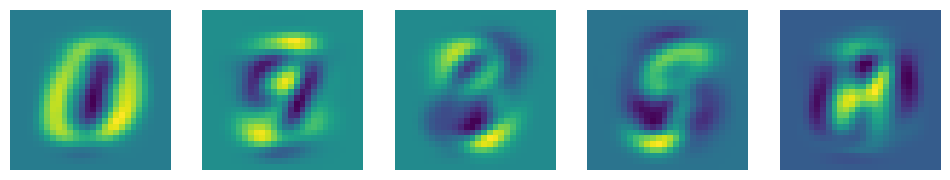

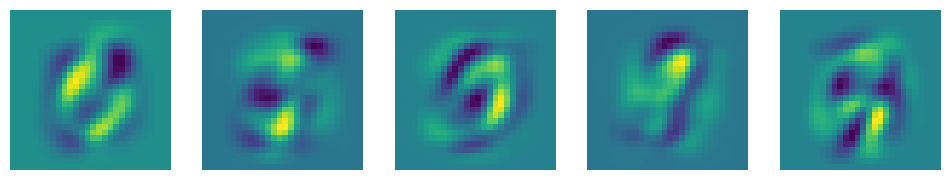

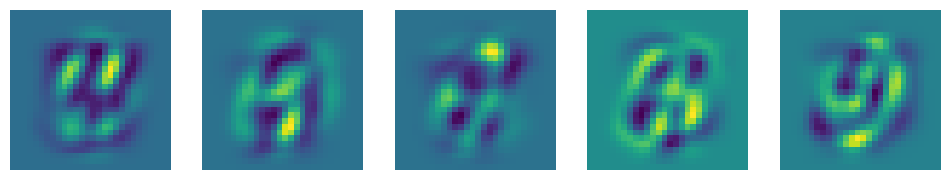

In [8]:
fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(12,4))
for i in range(5):
  ax[i].imshow(W[i].reshape(28,28))
  ax[i].set_axis_off()
fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(12,4))
for i in range(5):
  ax[i].imshow(W[i+5].reshape(28,28))
  ax[i].set_axis_off()
fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(12,4))
for i in range(5):
  ax[i].imshow(W[i+10].reshape(28,28))
  ax[i].set_axis_off()

## 6. Manual Reconstruction of the PCA Transformation

Scikit-learn's PCA transform is reproduced directly using:

\[
P = (X-b)W^T
\]

In [9]:
p = np.matmul((X_train-b),W.T)
print(f'{p.shape = }')

p.shape = (60000, 392)


### Transformation Equivalence

In [10]:
print(np.mean((X_train_pc-p)**2))

2.5416274e-14


The saved mean squared difference between the library transformation and the manually computed transformation is approximately:

```text
1.8634e-14
```

which is numerical roundoff.

## 7. Variance in Principal-Component Space

The per-coordinate variance of the manually transformed data is plotted first, followed by `pca.explained_variance_`.

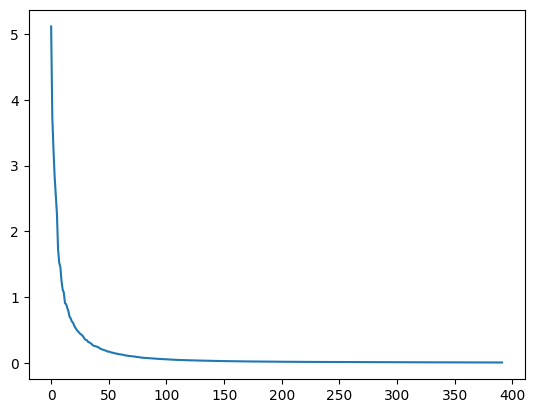

In [11]:
v = np.var(p,axis=0)
plt.plot(v)

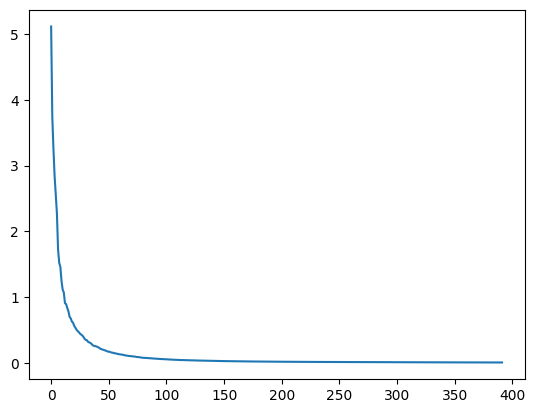

In [12]:
plt.plot(pca.explained_variance_)

### Normalized Cumulative Variance Across the Retained Components

The original calculation accumulates the retained component variances and normalizes them by the total variance represented by the 392 retained components.

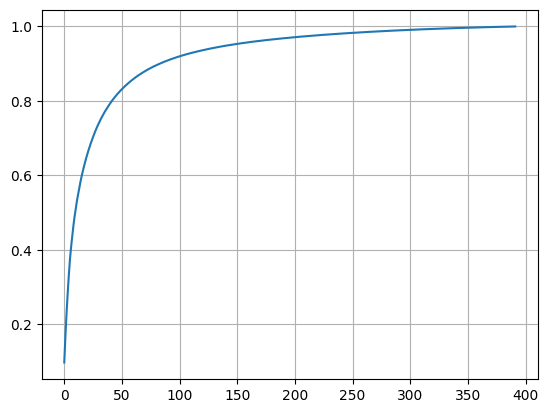

In [13]:
ev = np.cumsum(pca.explained_variance_)
ev = ev/ev[-1]
plt.plot(ev)
plt.grid(True)

## 8. Inverse Transformation and Image Reconstruction

The transformed representation is projected back into the original 784-dimensional pixel space:

\[
X_r = PW + b
\]

In [14]:
W.shape

(392, 784)

In [15]:
Xr =  np.matmul(p,W) + b

### Reconstruction Quality at Increasing Numbers of Components

Five randomly selected training images are reconstructed using 2, 4, 8, 16, 32, 64, 128, and 256 principal components, followed by the original images for visual comparison.

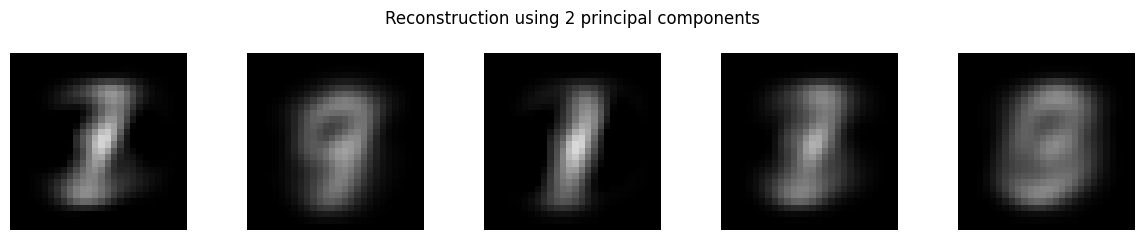

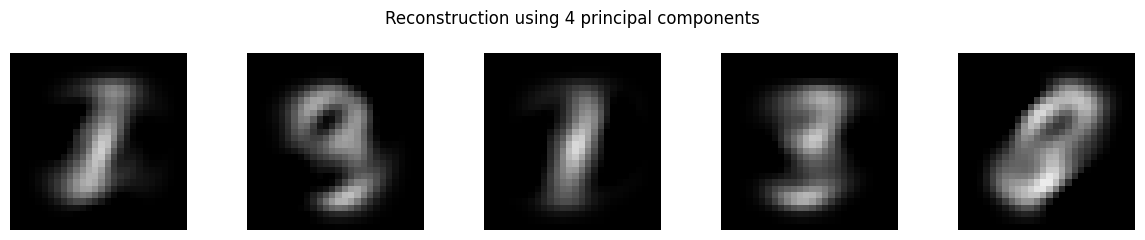

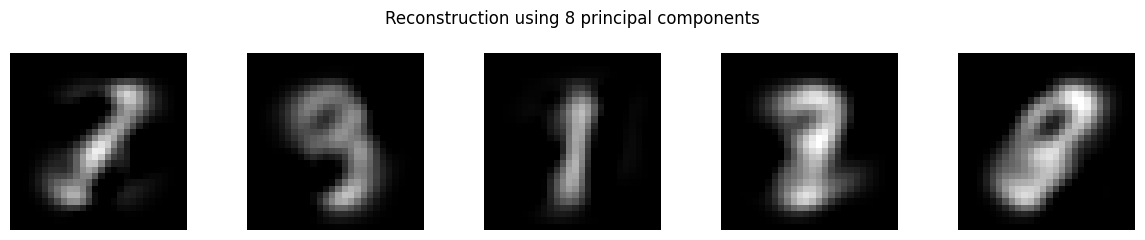

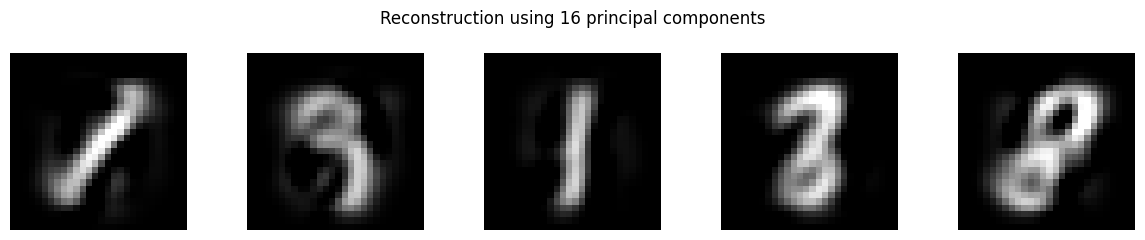

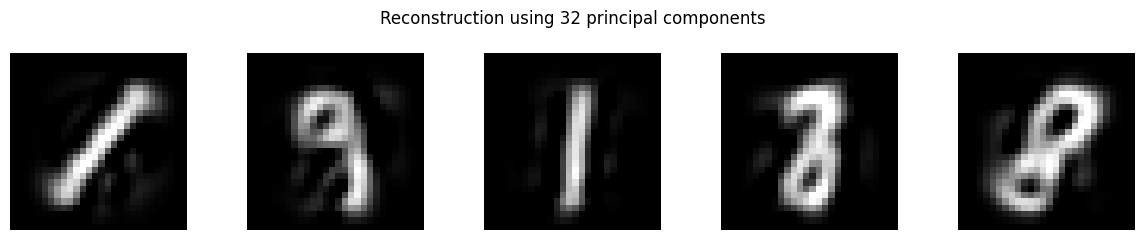

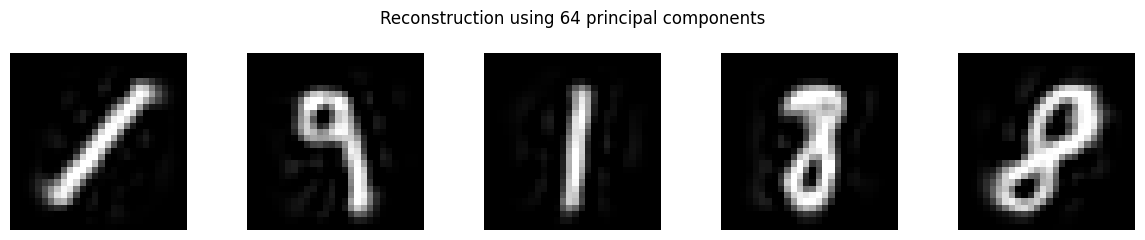

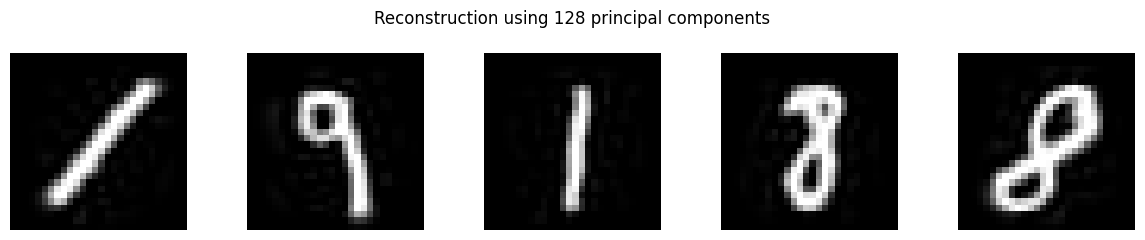

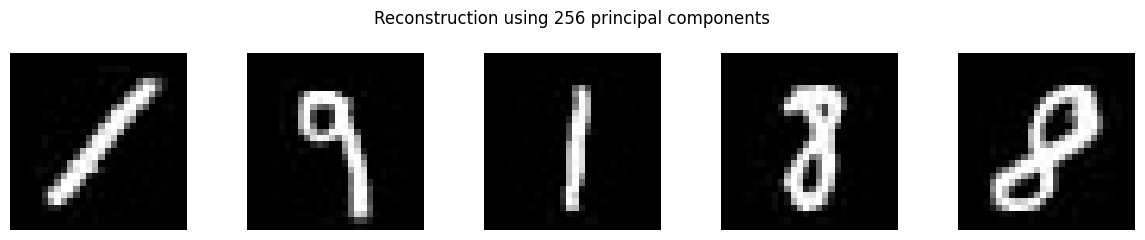

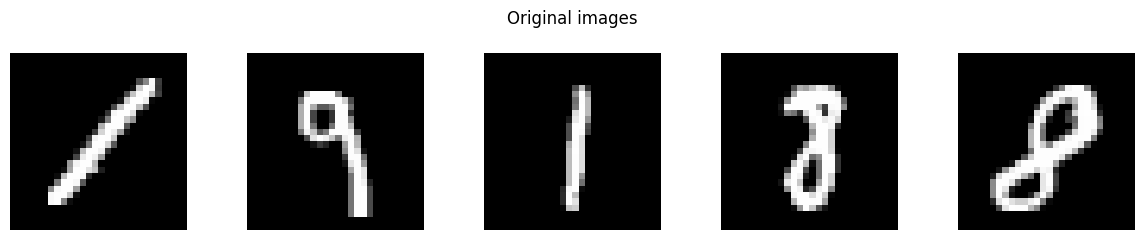

In [16]:
sel = np.random.randint(0,X_train.shape[0],size = 5)
for n in [2**i for i in range(1,9)]:
  r = np.matmul(p[:,:n],W[:n]) + b
  fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(12,2.4),layout='tight')
  #fig.supxlabel(f'Reconstruction using {n} principal components')
  for i,s in enumerate(sel):
    ax[i].imshow(r[s].reshape(28,28),vmin=0., vmax=1.,cmap='gray')
    ax[i].set_axis_off()
  fig.suptitle(f'Reconstruction using {n} principal components')
  plt.show()

fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(12,2.4),layout='tight')
fig.suptitle('Original images')
for i,s in enumerate(sel):
  ax[i].imshow(X_train[s].reshape(28,28),vmin=0., vmax=1.,cmap='gray')
  ax[i].set_axis_off()
plt.show()


## 9. Reconstruction Error vs. Number of Components

Reconstruction MSE is calculated every five components from 5 through 390.

In [17]:
mse_list = []
for n in range(5,392,5):
  r = np.matmul(p[:,:n],W[:n]) + b
  mse = np.mean((r-X_train)**2)
  print(f'Reconstruction with {n} principal components, mse = {mse}')
  mse_list.append(mse)

Reconstruction with 5 principal components, mse = 0.0449051596224308
Reconstruction with 10 principal components, mse = 0.03442259132862091
Reconstruction with 15 principal components, mse = 0.028290091082453728
Reconstruction with 20 principal components, mse = 0.023969681933522224
Reconstruction with 25 principal components, mse = 0.020726516842842102
Reconstruction with 30 principal components, mse = 0.01812129281461239
Reconstruction with 35 principal components, mse = 0.016059720888733864
Reconstruction with 40 principal components, mse = 0.01438454631716013
Reconstruction with 45 principal components, mse = 0.012970070354640484
Reconstruction with 50 principal components, mse = 0.011792738921940327
Reconstruction with 55 principal components, mse = 0.010783344507217407
Reconstruction with 60 principal components, mse = 0.009910468943417072
Reconstruction with 65 principal components, mse = 0.009140130132436752
Reconstruction with 70 principal components, mse = 0.00847533438354730

### Reconstruction-Error Curve

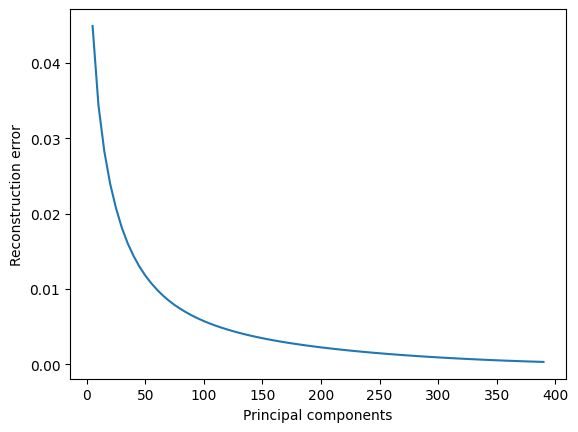

In [18]:
plt.plot(np.arange(5,392,5),mse_list)
plt.ylabel('Reconstruction error')
plt.xlabel('Principal components')
plt.show()

The saved reconstruction MSE decreases from approximately **0.04491 with 5 components** to **0.000324 with 390 components**, showing the expected improvement as more information is retained.

## 10. Classification Using PCA Features

The next experiments evaluate how predictive performance changes as more principal components are supplied to different model families.

### Linear Regression as a Multiclass Predictor

One-hot targets are fitted with linear regression, and the class with the largest predicted output is selected.

In [19]:
for n in range(20, 392, 20):
    model = LinearRegression()
    model.fit(X_train_pc[:, :n], y_train_oh)
    pred = model.predict(X_test_pc[:, :n])
    accuracy = accuracy_score(y_test, np.argmax(pred, axis=1))
    print(f'n = {n}, Accuracy {accuracy:.4}')

n = 20, Accuracy 0.8112
n = 40, Accuracy 0.8461
n = 60, Accuracy 0.8561
n = 80, Accuracy 0.8607
n = 100, Accuracy 0.8611
n = 120, Accuracy 0.8609
n = 140, Accuracy 0.8612
n = 160, Accuracy 0.8608
n = 180, Accuracy 0.8609
n = 200, Accuracy 0.8618
n = 220, Accuracy 0.8614
n = 240, Accuracy 0.8619
n = 260, Accuracy 0.8612
n = 280, Accuracy 0.8623
n = 300, Accuracy 0.8608
n = 320, Accuracy 0.8601
n = 340, Accuracy 0.8608
n = 360, Accuracy 0.8599
n = 380, Accuracy 0.8593


The saved linear-regression sweep peaks at approximately **0.8623 accuracy with 280 principal components**.

### Logistic Regression

Logistic regression is evaluated from 20 through 380 retained components.

In [20]:
for n in range(20, 392, 20):
    model = LogisticRegression()
    model.fit(X_train_pc[:, :n], y_train)
    pred = model.predict_proba(X_test_pc[:, :n])
    accuracy = accuracy_score(y_test, np.argmax(pred, axis=1))
    print(f'n = {n}, Accuracy {accuracy:.4}')

n = 20, Accuracy 0.8802
n = 40, Accuracy 0.9069
n = 60, Accuracy 0.9164
n = 80, Accuracy 0.9184
n = 100, Accuracy 0.922
n = 120, Accuracy 0.9237
n = 140, Accuracy 0.924
n = 160, Accuracy 0.9237
n = 180, Accuracy 0.9261
n = 200, Accuracy 0.9258
n = 220, Accuracy 0.9247


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n = 240, Accuracy 0.9258


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n = 260, Accuracy 0.9262
n = 280, Accuracy 0.9258


...

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n = 340, Accuracy 0.9243


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n = 360, Accuracy 0.925
n = 380, Accuracy 0.9251


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The saved successful runs reach approximately **0.9263 accuracy at 260 principal components**.

### Multilayer Perceptron

A one-hidden-layer MLP with early stopping is evaluated over increasing PCA dimensions.

In [21]:
for n in range(20, 392, 20):
    model = MLPClassifier(hidden_layer_sizes=(100,), early_stopping=True)
    model.fit(X_train_pc[:, :n], y_train)
    pred = model.predict_proba(X_test_pc[:, :n])
    accuracy = accuracy_score(y_test, np.argmax(pred, axis=1))
    print(f'n = {n}, Accuracy {accuracy:.4}')

n = 20, Accuracy 0.9728
n = 40, Accuracy 0.9776
n = 60, Accuracy 0.9771
n = 80, Accuracy 0.9776
n = 100, Accuracy 0.9766
n = 120, Accuracy 0.9803
n = 140, Accuracy 0.9765
n = 160, Accuracy 0.9768
n = 180, Accuracy 0.9773
n = 200, Accuracy 0.9772
n = 220, Accuracy 0.9771
n = 240, Accuracy 0.9754
n = 260, Accuracy 0.9757
n = 280, Accuracy 0.9732
n = 300, Accuracy 0.975
n = 320, Accuracy 0.9734
n = 340, Accuracy 0.9754
n = 360, Accuracy 0.9758
n = 380, Accuracy 0.975


Among the saved successful runs, the strongest accuracy is approximately **0.9793 at 180 principal components**.

### Randomized Decision Tree

A decision tree using entropy and randomized splitting is evaluated from 5 through 100 principal components.

In [22]:
model = DecisionTreeClassifier(criterion='entropy', splitter='random')

for n in range(5, 101, 5):
    model.fit(X_train_pc[:, :n], y_train)
    pred = model.predict(X_test_pc[:, :n])
    accuracy = accuracy_score(y_test, pred)
    print(f'n = {n}, Accuracy {accuracy:.4}')

n = 5, Accuracy 0.6576
n = 10, Accuracy 0.8146
n = 15, Accuracy 0.8394
n = 20, Accuracy 0.8489
n = 25, Accuracy 0.8408
n = 30, Accuracy 0.8411
n = 35, Accuracy 0.8314
n = 40, Accuracy 0.8363
n = 45, Accuracy 0.8407
n = 50, Accuracy 0.835
n = 55, Accuracy 0.8326
n = 60, Accuracy 0.8336
n = 65, Accuracy 0.8304
n = 70, Accuracy 0.8366
n = 75, Accuracy 0.8338
n = 80, Accuracy 0.8313
n = 85, Accuracy 0.8224
n = 90, Accuracy 0.8283
n = 95, Accuracy 0.8253
n = 100, Accuracy 0.8288


The saved decision-tree sweep reaches approximately **0.8465 accuracy with 30 principal components**.

## 11. Key Findings

- PCA reduces MNIST from 784 dimensions while preserving substantial predictive information.
- Principal directions are unit-length and mutually orthogonal up to numerical precision.
- The manual transformation reproduces scikit-learn's transformation to floating-point precision.
- Reconstruction error falls steadily as additional components are retained.
- Different predictive models benefit from different PCA dimensionalities.
- The strongest saved classification result in these experiments comes from the MLP using a reduced PCA representation.